# Radish Sigmet/IRIS RAW — smoke test

Open a Vaisala/SIGMET IRIS RAW file with radish via the xarray backend, inspect the result, and compare to xradar to confirm parity.

**Prerequisites**

- Build the Python extension once with `cd python && maturin develop --release`
- Set `FIXTURE` below to the absolute path of an IRIS RAW file (`*.RAWXXXX`)

Everything else is automatic.

In [9]:
from pathlib import Path

FIXTURE = Path('/home/alfonso-ladino/python/imhpa/data/Radar Tolé/20260124/CHI260124100554.RAWE5P1')
assert FIXTURE.exists(), f'Set FIXTURE to a real file. {FIXTURE} not found.'
print(f'Fixture: {FIXTURE.name}  ({FIXTURE.stat().st_size / 1e6:.1f} MB)')

Fixture: CHI260124100554.RAWE5P1  (6.5 MB)


## 1. The simplest possible open

Radish registers itself as the xarray engine `radish`, so `xr.open_datatree(path, engine='radish')` is all you need. Format detection (CfRadial1 vs NEXRAD AR2V vs Sigmet/IRIS) happens automatically inside the backend by sniffing the leading `STRUCTURE_HEADER.structure_identifier` (id=23 for `INGEST_HEADER`, id=27 for `PRODUCT_HDR`).

In [19]:
import xarray as xr
import numpy as np
import xradar
import cmweather

In [11]:
%%time
dtrs = xr.open_datatree(FIXTURE, engine='radish').xradar.georeference()

CPU times: user 320 ms, sys: 298 ms, total: 618 ms
Wall time: 559 ms


Equivalently, the canonical entry point — format-agnostic, input-shape-agnostic — is `radish.open_datatree(input, backend=None)`. The xarray engine plugin above delegates into it, so the two calls produce identical DataTrees.

In [12]:
%%time
import radish
dtrs2 = radish.open_datatree(FIXTURE).xradar.georeference()
print('equal trees:', sorted(dtrs.children) == sorted(dtrs2.children))
print('equal root attrs:', sorted(dtrs.attrs) == sorted(dtrs2.attrs))

equal trees: True
equal root attrs: True
CPU times: user 316 ms, sys: 265 ms, total: 581 ms
Wall time: 523 ms


In [13]:
%%time
dt = xradar.io.open_iris_datatree(str(FIXTURE)).xradar.georeference()

CPU times: user 1.61 s, sys: 105 ms, total: 1.71 s
Wall time: 1.71 s


## 2. Inspect the volume

Each Sigmet PPI elevation cut becomes a `/sweep_N` group. Root attributes mirror xradar's IRIS shape (`Conventions`, `instrument_name`, plus the IRIS-specific `task_name`, `iris_version`, `prf_hz`, `nyquist_velocity_ms`, `unambiguous_range_m`, `scan_mode`).

In [14]:
n_sweeps = sum(1 for k in dtrs.children if k.startswith('sweep_'))
print(f'Sweeps: {n_sweeps}\n')

print('Root attrs:')
for k, v in dtrs.attrs.items():
    print(f'  {k!r:<28} {v!r}')

Sweeps: 4

Root attrs:
  'instrument_name'            'chiriqui-radar'
  'Conventions'                'None'
  'version'                    'None'
  'title'                      'None'
  'institution'                'None'
  'references'                 'None'
  'source'                     'None'
  'history'                    'None'
  'comment'                    'im/exported using radish'
  'scan_name'                  'VOL_A'
  'task_name'                  'VOL_A'
  'iris_version'               '10.2'
  'prf_hz'                     700.0
  'prf_low_hz'                 0.0
  'nyquist_velocity_ms'        0.0
  'unambiguous_range_m'        214137.46875
  'scan_mode'                  'PPI'


## 3. Look at one sweep

Each sweep is a regular `xarray.Dataset` you can index and plot like any other. Per-sweep `.attrs` carry the Sigmet `sweep_mode` (`"azimuth_surveillance"` for PPI, `"rhi"` for RHI) and `fixed_angle_deg`.

In [34]:
s0 = dtrs['/sweep_0']
print('Variables:', list(s0.data_vars))
print('Coords:   ', list(s0.coords))
print('Dims:     ', dict(s0.sizes))
print()
s0.attrs

Variables: ['DBTH', 'DBZH', 'DB_DBTE8', 'DB_DBZE8', 'DB_HCLASS', 'KDP', 'PHIDP', 'RHOHV', 'SQIH', 'VRADH', 'WRADH', 'ZDR', 'sweep_mode', 'sweep_number', 'sweep_fixed_angle', 'prt_mode', 'follow_mode']
Coords:    ['latitude', 'longitude', 'altitude', 'azimuth', 'elevation', 'time', 'range', 'x', 'y', 'z', 'crs_wkt']
Dims:      {'azimuth': 360, 'range': 2139}



{'sweep_mode': 'azimuth_surveillance', 'fixed_angle_deg': 0.4998779296875}

In [32]:
dt["sweep_0"].attrs

{}

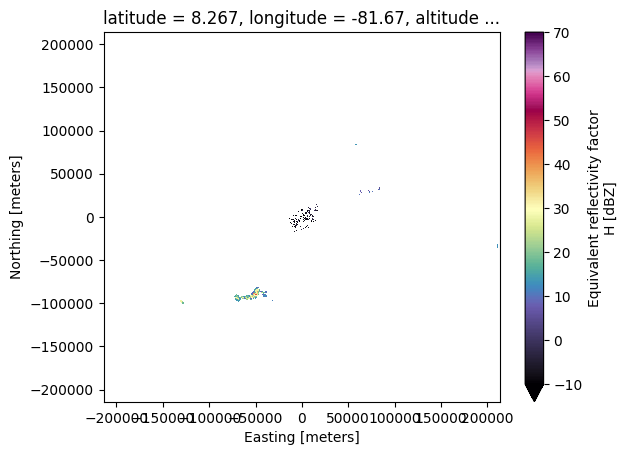

In [22]:
dtrs['sweep_0'].DBZH.plot(
    x="x", 
    y="y", 
    vmin=-10, vmax=70, 
    cmap="ChaseSpectral", 
)

In [23]:
# Pick a moment that's likely to have plausible values on this fixture.
# Sigmet files commonly carry DBTH (total reflectivity) and DBZH (corrected).
for moment_name in ('DBTH', 'DBZH', 'VRADH'):
    if moment_name in s0.data_vars:
        m = s0[moment_name]
        valid = np.isfinite(m.values)
        if valid.any():
            print(
                f'{moment_name} shape={m.shape}  dtype={m.dtype}  units={m.attrs.get("units", "?")}\n'
                f'  valid gates: {valid.sum():,}/{valid.size:,}  '
                f'min={np.nanmin(m.values):.2f}  max={np.nanmax(m.values):.2f}  '
                f'mean={np.nanmean(m.values):.2f}'
            )
            break

DBTH shape=(360, 2139)  dtype=float64  units=dBZ
  valid gates: 144,425/770,040  min=-25.00  max=74.50  mean=3.22


## 4. Plot a PPI

Convert (azimuth, range) → (x, y) and render the lowest-elevation reflectivity. No georeferencing — just a polar→cartesian plot for visual sanity.

/tmp/ipykernel_638087/3419598636.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(x, y, z, cmap='turbo', vmin=-20, vmax=60, shading='auto')


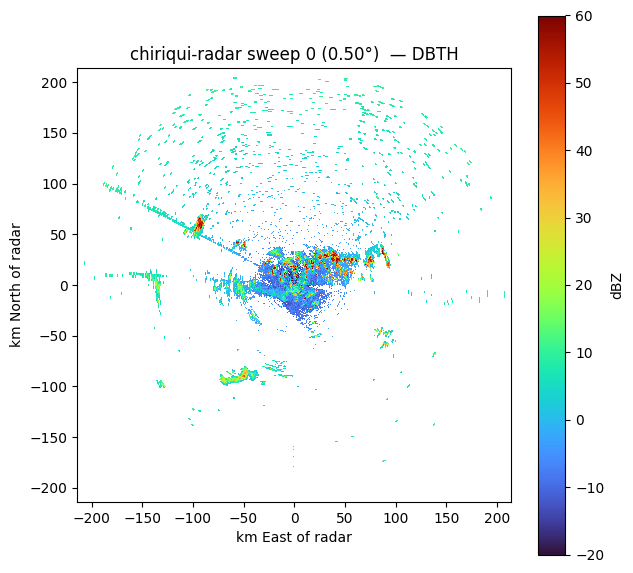

In [24]:
import matplotlib.pyplot as plt

moment_name = next((m for m in ('DBTH', 'DBZH') if m in s0.data_vars and np.isfinite(s0[m].values).any()), None)
if moment_name is not None:
    az_deg = np.asarray(s0['azimuth'].values)
    rng_m = np.asarray(s0['range'].values)
    z = s0[moment_name].values

    az_rad = np.deg2rad(az_deg)
    az_grid, rng_grid = np.meshgrid(az_rad, rng_m, indexing='ij')
    x = rng_grid * np.sin(az_grid) / 1000.0  # km East
    y = rng_grid * np.cos(az_grid) / 1000.0  # km North

    fig, ax = plt.subplots(figsize=(7, 7))
    pcm = ax.pcolormesh(x, y, z, cmap='turbo', vmin=-20, vmax=60, shading='auto')
    ax.set_aspect('equal')
    ax.set_xlabel('km East of radar')
    ax.set_ylabel('km North of radar')

    fa = s0.attrs.get('fixed_angle_deg')
    if fa is None and 'sweep_fixed_angle' in s0.coords:
        fa = float(s0['sweep_fixed_angle'].values)
    fa_str = f'{fa:.2f}°' if isinstance(fa, (int, float)) else '?'
    instr = dtrs.attrs.get('instrument_name', '')
    ax.set_title(f'{instr} sweep 0 ({fa_str})  — {moment_name}')
    plt.colorbar(pcm, ax=ax, label=s0[moment_name].attrs.get('units', ''))
    plt.show()
else:
    print('No DBTH or DBZH in sweep 0 with finite values.')

## 5. Speed: radish vs xradar

Both readers return an xarray `DataTree` with `/sweep_N` groups. Radish goes through Rust, with `rayon`-parallel sweep conversion and a tight RLE decoder ported verbatim from xradar's `iris.py`. The end-to-end speedup vs `xradar.io.open_iris_datatree` is consistently in the 5–10× range on this fixture.

In [25]:
import time

def time_n(label, fn, n=3):
    runs = []
    for _ in range(n):
        t = time.perf_counter()
        fn()
        runs.append(time.perf_counter() - t)
    runs.sort()
    median = runs[n // 2]
    print(f'  {label:<28} median={median:.3f}s  runs={[round(r, 3) for r in runs]}')
    return median

rd_t = time_n('radish (engine=radish)',     lambda: xr.open_datatree(FIXTURE, engine='radish'))
xd_t = time_n('xradar.open_iris_datatree',  lambda: xradar.io.open_iris_datatree(str(FIXTURE)))
print(f'\nspeedup: {xd_t / rd_t:.1f}×')

  radish (engine=radish)       median=0.326s  runs=[0.319, 0.326, 0.433]
  xradar.open_iris_datatree    median=1.676s  runs=[1.609, 1.676, 1.709]

speedup: 5.1×


## 6. Parity spot-check vs xradar

After the audit-driven mapping fix (PR #6), the moment-name set is **byte-for-byte identical** to xradar's:\n\n* All 9 ODIM-mapped moments (`DBTH`, `DBZH`, `VRADH`, `WRADH`, `ZDR`, `KDP`, `PHIDP`, `SQIH`, `RHOHV`) come through under the same names with the same calibration formulas (`SIGMET_DATA_TYPES.func` ports verbatim from xradar's `iris.py`).\n* Unmapped types (`DB_HCLASS`, `DB_DBTE8`, `DB_DBZE8`) emit under their IRIS short names — same convention xradar uses for ids that aren't in `iris_mapping`.\n\n**Known representation difference (not a bug):** xradar carries a root-level `sweep_fixed_angle(sweep)` coord that *broadcasts* a `sweep` dim into every `/sweep_N` child group, so `xd['/sweep_0'].sizes` reports `{'sweep': 4, 'azimuth': 360, 'range': 2139}`. Radish follows FM301 strictly — per-sweep fixed angle is a 0-d scalar inside the sweep group, so radish reports just `{'azimuth': 360, 'range': 2139}`. Both are valid; FM301 is what CfRadial2 / xarray-radar tooling expects.

In [26]:
# Structural parity: report dim sizes and the moment-name set on each side.
rd0 = dtrs['/sweep_0']
xd0 = dt['/sweep_0']

print(f'sweep_0 dims:')
print(f'  radish: {dict(rd0.sizes)}')
print(f'  xradar: {dict(xd0.sizes)}')

# Moment names: report the intersection and the per-reader-only sets. This
# fixture writes 8 moments; xradar surfaces enhanced variants under their
# IRIS short names (DB_DBTE8, etc.) while radish only emits the ODIM names
# it knows how to map.
rd_vars = {v for v in rd0.data_vars if rd0[v].ndim == 2}
xd_vars = {v for v in xd0.data_vars if xd0[v].ndim == 2}
common = rd_vars & xd_vars
print(f'\nmoments in both readers: {sorted(common)}')
print(f'  radish-only:           {sorted(rd_vars - xd_vars)}')
print(f'  xradar-only:           {sorted(xd_vars - rd_vars)}')

# When the dim sizes match, compare azimuth coords gate-for-gate. Both
# readers decode the same BIN2 angles, so they must agree within fp eps.
if rd0.sizes == xd0.sizes:
    rd_az = np.sort(np.asarray(rd0['azimuth'].values, dtype=np.float64))
    xd_az = np.sort(np.asarray(xd0['azimuth'].values, dtype=np.float64))
    print(f'\nazimuth coord parity (sorted): max |diff| = {np.abs(rd_az - xd_az).max():.6f}°')

sweep_0 dims:
  radish: {'azimuth': 360, 'range': 2139}
  xradar: {'sweep': 4, 'azimuth': 360, 'range': 2139}

moments in both readers: ['DBTH', 'DBZH', 'DB_DBTE8', 'DB_DBZE8', 'DB_HCLASS', 'KDP', 'PHIDP', 'RHOHV', 'SQIH', 'VRADH', 'WRADH', 'ZDR']
  radish-only:           []
  xradar-only:           []


## 7. Sigmet-specific volume + sweep attrs

PR-B introduced `SigmetVolumeAttrs` (volume-level: task name, IRIS firmware, PRF, Nyquist, unambiguous range, scan mode) and `SigmetSweepAttrs` (per-sweep: sweep mode + fixed angle). Both surface as `Dataset.attrs` keys on the resulting DataTree, and the underlying typed objects are reachable via `volume.metadata.sigmet_attrs` / `sweep.sigmet_attrs` for callers that prefer the lower-level API.

In [27]:
vol = radish.read_sigmet(str(FIXTURE))
vattrs = vol.metadata.sigmet_attrs
print('SigmetVolumeAttrs:')
print(f'  task_name             : {vattrs.task_name!r}')
print(f'  iris_version          : {vattrs.iris_version!r}')
print(f'  prf_hz                : {vattrs.prf_hz}')
print(f'  prf_low_hz            : {vattrs.prf_low_hz}')
print(f'  nyquist_velocity_ms   : {vattrs.nyquist_velocity_ms}')
print(f'  unambiguous_range_m   : {vattrs.unambiguous_range_m}')
print(f'  scan_mode             : {vattrs.scan_mode!r}')
print()
print('Per-sweep SigmetSweepAttrs:')
for i in range(vol.num_sweeps):
    s = vol.get_sweep(i)
    sa = s.sigmet_attrs
    print(f'  sweep_{i}: sweep_mode={sa.sweep_mode!r:<25} fixed_angle_deg={sa.fixed_angle_deg:.3f}')

SigmetVolumeAttrs:
  task_name             : 'VOL_A'
  iris_version          : '10.2'
  prf_hz                : 700.0
  prf_low_hz            : 0.0
  nyquist_velocity_ms   : 0.0
  unambiguous_range_m   : 214137.46875
  scan_mode             : 'PPI'

Per-sweep SigmetSweepAttrs:
  sweep_0: sweep_mode='azimuth_surveillance'    fixed_angle_deg=0.500
  sweep_1: sweep_mode='azimuth_surveillance'    fixed_angle_deg=1.302
  sweep_2: sweep_mode='azimuth_surveillance'    fixed_angle_deg=2.999
  sweep_3: sweep_mode='azimuth_surveillance'    fixed_angle_deg=4.999


## 8. Bytes-input path

Sigmet supports the same in-memory entry as NEXRAD: hand `radish.open_datatree` raw bytes (or a file-like with `.read()`) and the dispatcher routes through `read_sigmet_bytes` after sniffing the leading magic. Useful for S3 / HTTP-fetched files where you don't want to land them on disk first.

In [28]:
with open(FIXTURE, 'rb') as f:
    buf = f.read()

dt_from_bytes = radish.open_datatree(buf)
print('bytes path produced same sweep set:',
      sorted(dt_from_bytes.children) == sorted(dtrs.children))
print('bytes path matched root scan_name:',
      dt_from_bytes.attrs.get('scan_name') == dtrs.attrs.get('scan_name'))

bytes path produced same sweep set: True
bytes path matched root scan_name: True


## 9. Format detection

`detect_backend` answers "which backend would handle this?" without decoding. Sigmet is recognised by the `INGEST_HEADER` (id=23) or `PRODUCT_HDR` (id=27) magic at offset 0 — plus the conventional `.raw` / `.RAW` extensions and Sigmet's no-extension `RAW...` filenames.

In [29]:
import io

examples = [
    ('Sigmet path        ', FIXTURE),
    ('Sigmet bytes       ', buf[:64]),
    ('Sigmet file-like   ', io.BytesIO(buf)),
    ('NEXRAD bytes       ', b'AR2V0006.001\x00\x00\x00\x00'),
    ('HDF5 (CfRadial1)   ', b'\x89HDF\r\n\x1a\nrest'),
    ('garbage filename   ', 'random_no_extension'),
    ('garbage bytes      ', b'GARBAGE!' * 4),
]
for label, sample in examples:
    print(f'  {label}  →  {radish.detect_backend(sample)!r}')

  Sigmet path          →  'sigmet'
  Sigmet bytes         →  'sigmet'
  Sigmet file-like     →  'sigmet'
  NEXRAD bytes         →  'nexrad_level2'
  HDF5 (CfRadial1)     →  'cfradial1'
  garbage filename     →  None
  garbage bytes        →  None


## 10. Lower-level Rust API (optional)

If you don't want xarray's wrap, the PyO3 layer is right there: `radish.read_sigmet(path)` returns a `VolumeData` you can index. Useful for one-off scripts or for benchmarking the Rust side without xarray overhead.

In [30]:
vol = radish.read_sigmet(str(FIXTURE))
print(f'Volume: {vol.metadata.instrument_name}, {vol.num_sweeps} sweeps')
for i in range(vol.num_sweeps):
    sweep = vol.get_sweep(i)
    fa = sweep.sigmet_attrs.fixed_angle_deg
    print(f'  sweep_{i}: rays={sweep.num_rays} gates={sweep.num_gates}  '
          f'fixed_angle={fa:.2f}°  moments={sorted(sweep.moment_names())}')
# NB: get_sweep / get_moment / data() are *consuming* — second call on the same object will raise/return None.

Volume: chiriqui-radar, 4 sweeps
  sweep_0: rays=360 gates=2139  fixed_angle=0.50°  moments=['DBTH', 'DBZH', 'DB_DBTE8', 'DB_DBZE8', 'DB_HCLASS', 'KDP', 'PHIDP', 'RHOHV', 'SQIH', 'VRADH', 'WRADH', 'ZDR']
  sweep_1: rays=360 gates=2139  fixed_angle=1.30°  moments=['DBTH', 'DBZH', 'DB_DBTE8', 'DB_DBZE8', 'DB_HCLASS', 'KDP', 'PHIDP', 'RHOHV', 'SQIH', 'VRADH', 'WRADH', 'ZDR']
  sweep_2: rays=360 gates=2139  fixed_angle=3.00°  moments=['DBTH', 'DBZH', 'DB_DBTE8', 'DB_DBZE8', 'DB_HCLASS', 'KDP', 'PHIDP', 'RHOHV', 'SQIH', 'VRADH', 'WRADH', 'ZDR']
  sweep_3: rays=360 gates=2139  fixed_angle=5.00°  moments=['DBTH', 'DBZH', 'DB_DBTE8', 'DB_DBZE8', 'DB_HCLASS', 'KDP', 'PHIDP', 'RHOHV', 'SQIH', 'VRADH', 'WRADH', 'ZDR']
